In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   --- ------------------------------------ 9.7/101.7 MB 50.2 MB/s eta 0:00:02
   ------- -------------------------------- 18.9/101.7 MB 47.6 MB/s eta 0:00:02
   ------------ --------------------------- 30.9/101.7 MB 50.3 MB/s eta 0:00:02
   -------------- ------------------------- 37.2/101.7 MB 45.5 MB/s eta 0:00:02
   ------------------ --------------------- 48.2/101.7 MB 48.7 MB/s eta 0:00:02
   ---------------------- ----------------- 56.1/101.7 MB 45.2 MB/s eta 0:00:02
   -------------------------- ------------- 67.9/101.7 MB 46.5 MB/s eta 0:00:01
   ------------------------------- -------- 80.7/101.7 MB 48.6 MB/s eta 0:00:01
   ----------------------------------- ---- 90.2/101.7 MB 49.6 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 49.0 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 46.7 MB/s  0:00:02


In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [6]:
df_final_grouped = pd.read_csv('../../data/final/df_final_grouped.csv', keep_default_na = False)
print(df_final_grouped.shape)
df_final_grouped.columns

(278762, 24)


Index(['nct_id', 'overall_status', 'number_of_arms', 'intervention_count',
       'has_multiple_intervention_types', 'log_enrollment', 'log_duration',
       'high_enroll_flag_975', 'high_enroll_flag_99', 'has_dmc',
       'has_expanded_access', 'healthy_volunteers', 'is_fda_regulated_drug',
       'is_fda_regulated_device', 'phase_grouped', 'intervention_grouped',
       'condt_grouped', 'allocation_grouped', 'masking_grouped',
       'model_grouped', 'purpose_grouped', 'sponsor_grouped',
       'elig_gender_grouped', 'elig_age_grouped'],
      dtype='str')

In [7]:
# XGBoost Final Model (best params: scale_pos_weight=1, n_estimators=200, max_depth=8)

# Prepare Data
X = df_final_grouped.drop(columns=["overall_status", "nct_id", "high_enroll_flag_99"])
y = df_final_grouped["overall_status"]

# Encode categorical features (object -> int)
X_encoded = X.copy()
for col in X.select_dtypes("object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# Train XGBoost
xgb = XGBClassifier(
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=1,   # best param found
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

# Predictions
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

C:\Users\301-2\AppData\Local\Temp\ipykernel_6560\2450316988.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes("object").columns:
c:\Users\301-2\anaconda3\envs\ct_study\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:28:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [8]:
# Evaluation metrics
print("=== Metrics at threshold 0.5 ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1       :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Metrics at threshold 0.5 ===
Accuracy : 0.916
Precision: 0.921
Recall   : 0.987
F1       : 0.953
ROC-AUC  : 0.885

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.50      0.63      8008
           1       0.92      0.99      0.95     47745

    accuracy                           0.92     55753
   macro avg       0.89      0.74      0.79     55753
weighted avg       0.91      0.92      0.91     55753



In [11]:
# Save classification report
import os

# 1. 저장할 경로 설정
save_dir = "../results/model_xgb/"

# 2. 폴더가 없으면 생성 (exist_ok=True는 이미 폴더가 있어도 에러를 내지 않게 합니다)
os.makedirs(save_dir, exist_ok=True)

# 3. 파일 저장
with open(os.path.join(save_dir, "xgb_classification_report_default.txt"), "w") as f:
    f.write(classification_report(y_test, y_pred))

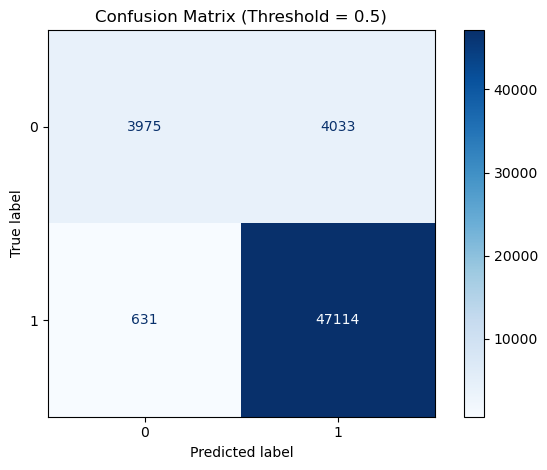

In [12]:
# Confusion Matrix at 0.5
cm_default = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm_default)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.tight_layout()
plt.savefig("../results/model_xgb/xgb_confusion_matrix_default.png", dpi=300)
plt.show()

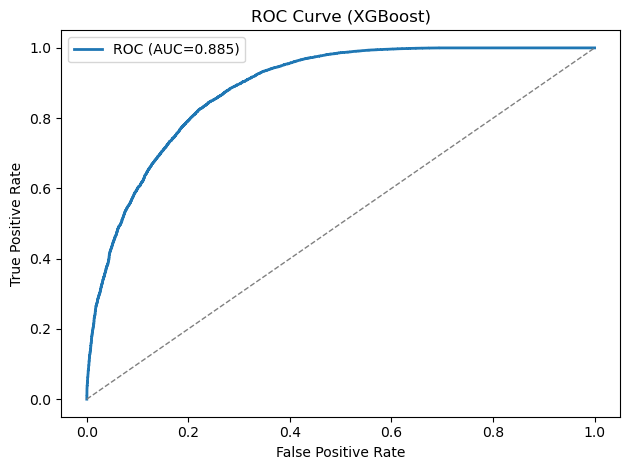

In [13]:
# ROC Curve
fpr, tpr, roc_th = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], "--", lw=1, color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (XGBoost)")
plt.legend()
plt.tight_layout()
plt.savefig("../results/model_xgb/xgb_roc_curve.png", dpi=300)
plt.show()

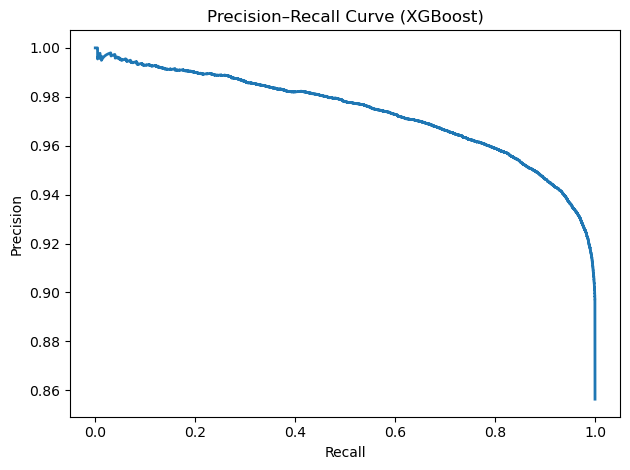

In [14]:
# Precision–Recall Curve
prec, rec, pr_th = precision_recall_curve(y_test, y_prob)
plt.figure()
plt.plot(rec, prec, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (XGBoost)")
plt.tight_layout()
plt.savefig("../results/model_xgb/xgb_precision_recall_curve.png", dpi=300)
plt.show()

In [15]:
# Optimal Threshold (Youden’s J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thr = roc_th[best_idx]

print(f"\nBest threshold by Youden J: {best_thr:.3f} (J={j_scores[best_idx]:.3f})")


Best threshold by Youden J: 0.871 (J=0.605)


In [16]:
y_pred_opt = (y_prob >= best_thr).astype(int)

print("\n=== Metrics at optimal threshold ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_opt), 3))
print("Precision:", round(precision_score(y_test, y_pred_opt), 3))
print("Recall   :", round(recall_score(y_test, y_pred_opt), 3))
print("F1       :", round(f1_score(y_test, y_pred_opt), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))


=== Metrics at optimal threshold ===
Accuracy : 0.833
Precision: 0.954
Recall   : 0.845
F1       : 0.897

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.76      0.57      8008
           1       0.95      0.85      0.90     47745

    accuracy                           0.83     55753
   macro avg       0.70      0.80      0.73     55753
weighted avg       0.88      0.83      0.85     55753



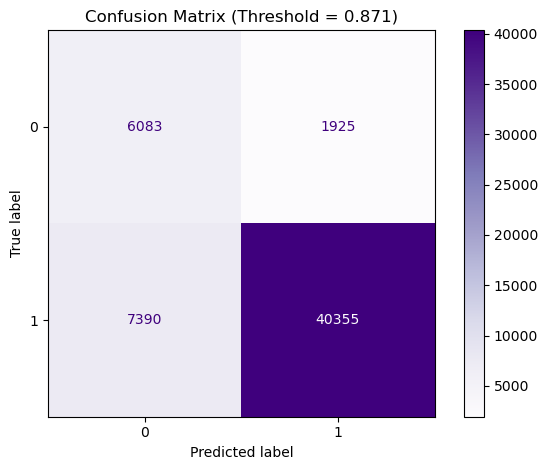

In [17]:
# Save classification report
with open("../results/model_xgb/xgb_classification_report_optimal.txt", "w") as f:
    f.write(classification_report(y_test, y_pred_opt))

# Save confusion matrix (optimal threshold)
cm_opt = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm_opt)
disp.plot(cmap="Purples", values_format="d")
plt.title(f"Confusion Matrix (Threshold = {best_thr:.3f})")
plt.tight_layout()
plt.savefig("../results/model_xgb/xgb_confusion_matrix_optimal.png", dpi=300)
plt.show()

In [18]:
# Save model and metrics
joblib.dump(xgb, "../models/xgb_pipeline.pkl")

# Save feature columns
joblib.dump(X.columns.tolist(), "../models/X_cols_xgb.pkl")

# Save metrics
metrics = {
    "Accuracy_0.5": round(accuracy_score(y_test, y_pred), 3),
    "Precision_0.5": round(precision_score(y_test, y_pred), 3),
    "Recall_0.5": round(recall_score(y_test, y_pred), 3),
    "F1_0.5": round(f1_score(y_test, y_pred), 3),
    "ROC_AUC": round(roc_auc_score(y_test, y_prob), 3),
    "Best_threshold": round(best_thr, 3),
    "Accuracy_opt": round(accuracy_score(y_test, y_pred_opt), 3),
    "Precision_opt": round(precision_score(y_test, y_pred_opt), 3),
    "Recall_opt": round(recall_score(y_test, y_pred_opt), 3),
    "F1_opt": round(f1_score(y_test, y_pred_opt), 3)
}

pd.DataFrame([metrics]).to_csv("../results/model_xgb/model_xgb_metrics.csv", index=False)

print("\n✅ Model, feature list, and metrics saved.")


✅ Model, feature list, and metrics saved.
